# Métodos de Análisis de Datos 1 — Unidad 2
## Análisis Exploratorio de Datos (EDA)
**Departamento de Matemática — Universidad Nacional del Sur**  
1er Cuatrimestre 2026

---
### Contenidos del notebook
| Clase | Tema |
|-------|------|
| 8 | Estadística descriptiva univariada |
| 9 | Análisis de distribuciones |
| 10 | Detección de outliers |
| 11 | Análisis bivariado |
| 12 | Visualización con Python |
| 13 | (Visualización avanzada — integración) |

**Datasets usados:** `iris` (sklearn), `tips` y `penguins` (seaborn)


## Configuración inicial

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Estilo general
#sns.set_theme(style='whitegrid', palette='steelblue')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (8, 4)

# Datasets
from sklearn.datasets import load_iris

iris_sk = load_iris(as_frame=True)
iris = iris_sk.frame
iris.columns = ['sepal_length', 'sepal_width',
                'petal_length', 'petal_width', 'species']
iris['species'] = iris['species'].map({0: 'setosa',
                                        1: 'versicolor',
                                        2: 'virginica'})

tips  = sns.load_dataset('tips')
penguins = sns.load_dataset('penguins').dropna()

print("iris:    ", iris.shape)
print("tips:    ", tips.shape)
print("penguins:", penguins.shape)


iris:     (150, 5)
tips:     (244, 7)
penguins: (333, 7)


---
## Clase 8 — Estadística Descriptiva Univariada

### 8.1 Resumen general con `describe()`


In [3]:
# Resumen estadístico completo
iris.describe().round(3)


,sepal_length,sepal_width,petal_length,petal_width
count,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199
std,0.828,0.436,1.765,0.762
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500


### 8.2 Medidas de posición central

In [4]:
col = 'sepal_length'

media   = iris[col].mean()
mediana = iris[col].median()
moda    = iris[col].mode()[0]

print(f"Media:   {media:.3f}")
print(f"Mediana: {mediana:.3f}")
print(f"Moda:    {moda:.3f}")


Media:   5.843
Mediana: 5.800
Moda:    5.000


### 8.3 Cuantiles

In [5]:
q = [0.10, 0.25, 0.50, 0.75, 0.90]
print("Cuantiles de sepal_length:")
print(iris['sepal_length'].quantile(q).round(3).to_string())


Cuantiles de sepal_length:
0.10    4.8
0.25    5.1
0.50    5.8
0.75    6.4
0.90    6.9


### 8.4 Medidas de dispersión

In [6]:
col = 'sepal_length'
s2  = iris[col].var(ddof=1)
s   = iris[col].std(ddof=1)
ric = iris[col].quantile(0.75) - iris[col].quantile(0.25)
cv  = s / iris[col].mean() * 100

print(f"Varianza (s²): {s2:.4f}")
print(f"Desvío est. (s): {s:.4f}")
print(f"Rango:  {iris[col].max() - iris[col].min():.4f}")
print(f"RIC:    {ric:.4f}")
print(f"CV:     {cv:.2f}%")


Varianza (s²): 0.6857
Desvío est. (s): 0.8281
Rango:  3.6000
RIC:    1.3000
CV:     14.17%


### 8.5 Medidas de forma

In [7]:
from scipy.stats import skew, kurtosis

col = 'sepal_length'
g1 = skew(iris[col])          # asimetría de Fisher
g2 = kurtosis(iris[col])      # exceso de curtosis

print(f"Asimetría (g1): {g1:.4f}")
print(f"Curtosis  (g2): {g2:.4f}")

if abs(g1) < 0.5:
    print("→ Distribución aproximadamente simétrica")
elif g1 > 0:
    print("→ Asimetría positiva (cola derecha)")
else:
    print("→ Asimetría negativa (cola izquierda)")


Asimetría (g1): 0.3118
Curtosis  (g2): -0.5736
→ Distribución aproximadamente simétrica


### 8.6 Tabla de frecuencias para variable continua

In [8]:
# Regla de Sturges
n = len(iris)
k = int(1 + 3.322 * np.log10(n))
print(f"n = {n}, k (Sturges) = {k}")

col = 'sepal_length'
freq, bins = np.histogram(iris[col], bins=k)

tabla = pd.DataFrame({
    'Límite inf': bins[:-1].round(2),
    'Límite sup': bins[1:].round(2),
    'Frec. abs': freq,
    'Frec. rel': (freq / n).round(4),
    'Frec. acum': (freq / n).cumsum().round(4)
})
print(tabla.to_string(index=False))


n = 150, k (Sturges) = 8
 Límite inf  Límite sup  Frec. abs  Frec. rel  Frec. acum
       4.30        4.75         11     0.0733      0.0733
       4.75        5.20         30     0.2000      0.2733
       5.20        5.65         24     0.1600      0.4333
       5.65        6.10         24     0.1600      0.5933
       6.10        6.55         31     0.2067      0.8000
       6.55        7.00         17     0.1133      0.9133
       7.00        7.45          7     0.0467      0.9600
       7.45        7.90          6     0.0400      1.0000


### 8.7 Resumen por grupos

In [9]:
iris.groupby('species')['sepal_length'].agg(
    n='count',
    media='mean',
    mediana='median',
    desvio='std',
    cv=lambda x: x.std()/x.mean()*100
).round(3)


,n,media,mediana,desvio,cv
species,,,,,
setosa,50,5.006,5.0,0.352,7.041
versicolor,50,5.936,5.9,0.516,8.696
virginica,50,6.588,6.5,0.636,9.652


---
## Clase 9 — Análisis de Distribuciones

### 9.1 Histograma con curva de densidad (KDE)


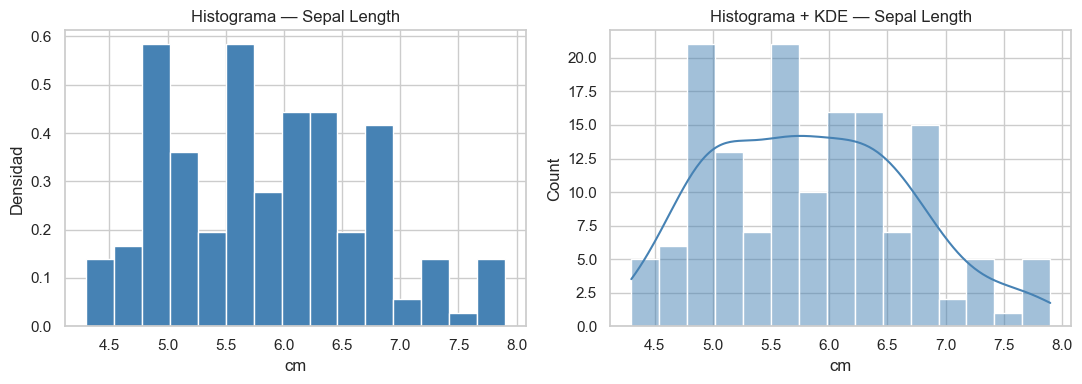

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Histograma simple
axes[0].hist(iris['sepal_length'], bins=15,
             color='steelblue', edgecolor='white',
             density=True)
axes[0].set_title('Histograma — Sepal Length')
axes[0].set_xlabel('cm')
axes[0].set_ylabel('Densidad')

# Histograma + KDE con seaborn
sns.histplot(iris['sepal_length'], kde=True,
             bins=15, ax=axes[1], color='steelblue')
axes[1].set_title('Histograma + KDE — Sepal Length')
axes[1].set_xlabel('cm')

plt.tight_layout()
plt.show()


### 9.2 Boxplot

C:\Users\jmbav\AppData\Local\Temp\ipykernel_24532\2468849496.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y='sepal_length',


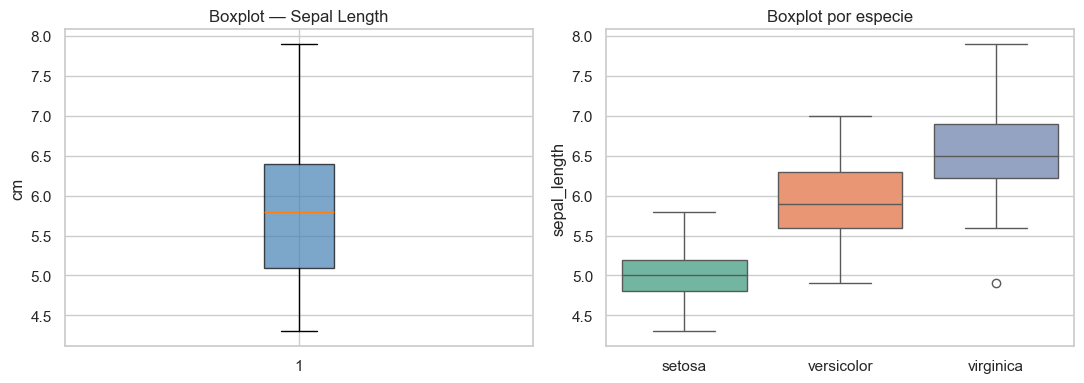

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Boxplot simple
axes[0].boxplot(iris['sepal_length'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[0].set_title('Boxplot — Sepal Length')
axes[0].set_ylabel('cm')

# Boxplot por especie
sns.boxplot(x='species', y='sepal_length',
            data=iris, ax=axes[1], palette='Set2')
axes[1].set_title('Boxplot por especie')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()


### 9.3 Q-Q Plot

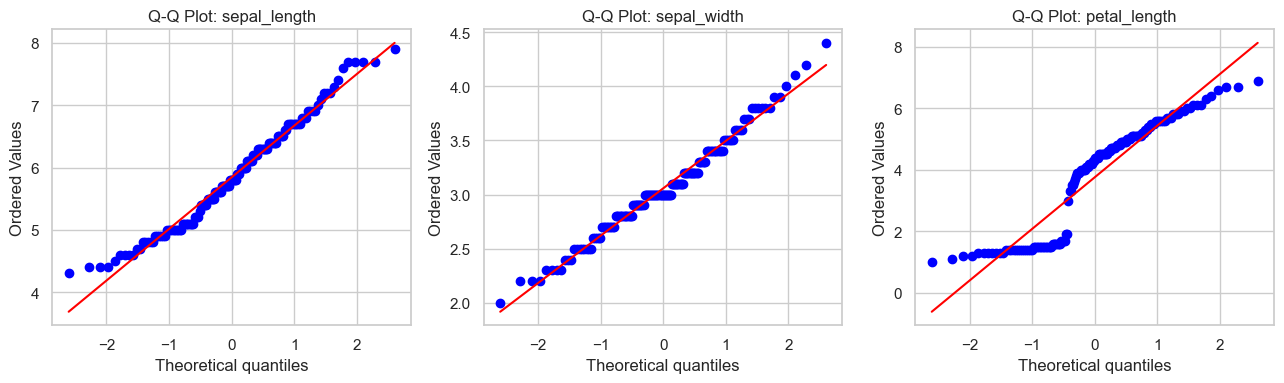

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

variables = ['sepal_length', 'sepal_width', 'petal_length']
for ax, var in zip(axes, variables):
    stats.probplot(iris[var], dist='norm', plot=ax)
    ax.set_title(f'Q-Q Plot: {var}')
    ax.get_lines()[1].set_color('red')

plt.tight_layout()
plt.show()


### 9.4 Pruebas de normalidad

In [13]:
from scipy.stats import shapiro, kstest, normaltest

print(f"{'Variable':<15} {'Shapiro W':>10} {'p-valor':>10} {'Normal?':>10}")
print("-" * 50)

for col in ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']:
    W, p = shapiro(iris[col])
    decision = "Sí" if p > 0.05 else "No"
    print(f"{col:<15} {W:>10.4f} {p:>10.4f} {decision:>10}")


Variable         Shapiro W    p-valor    Normal?
--------------------------------------------------
sepal_length        0.9761     0.0102         No
sepal_width         0.9849     0.1012         Sí
petal_length        0.8763     0.0000         No
petal_width         0.9018     0.0000         No


In [14]:
# Test de D'Agostino-Pearson (recomendado para n > 50)
from scipy.stats import normaltest

print(f"{'Variable':<15} {'Estadístico':>12} {'p-valor':>10} {'Normal?':>10}")
print("-" * 52)
for col in ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']:
    stat, p = normaltest(iris[col])
    decision = "Sí" if p > 0.05 else "No"
    print(f"{col:<15} {stat:>12.4f} {p:>10.4f} {decision:>10}")


Variable         Estadístico    p-valor    Normal?
----------------------------------------------------
sepal_length          5.7356     0.0568         Sí
sepal_width           3.1238     0.2097         Sí
petal_length        221.6873     0.0000         No
petal_width         137.5560     0.0000         No


---
## Clase 10 — Detección de Outliers

### 10.1 Criterio del boxplot (Tukey / IQR)


In [15]:
def detectar_outliers_iqr(serie, k=1.5):
    """Detecta outliers usando el criterio de Tukey (k=1.5 leve, k=3 extremo)."""
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - k * IQR
    lim_sup = Q3 + k * IQR
    outliers = serie[(serie < lim_inf) | (serie > lim_sup)]
    return outliers, lim_inf, lim_sup

col = 'sepal_width'
out_leve,  li_l, ls_l = detectar_outliers_iqr(iris[col], k=1.5)
out_extr,  li_e, ls_e = detectar_outliers_iqr(iris[col], k=3.0)

print(f"Variable: {col}")
print(f"  Outliers leves (k=1.5): {len(out_leve)} → límites [{li_l:.3f}, {ls_l:.3f}]")
print(f"  Outliers extremos (k=3): {len(out_extr)} → límites [{li_e:.3f}, {ls_e:.3f}]")


Variable: sepal_width
  Outliers leves (k=1.5): 4 → límites [2.050, 4.050]
  Outliers extremos (k=3): 0 → límites [1.300, 4.800]


### 10.2 Z-score y Z modificado (MAD)

In [16]:
def zscore_modificado(serie):
    """Z-score robusto de Iglewicz & Hoaglin (umbral: |M| > 3.5)."""
    mediana = serie.median()
    MAD = np.median(np.abs(serie - mediana))
    M = 0.6745 * (serie - mediana) / MAD
    return M

col = 'sepal_width'
z   = np.abs(stats.zscore(iris[col]))
M   = np.abs(zscore_modificado(iris[col]))

out_z = iris[col][z > 3]
out_M = iris[col][M > 3.5]

print(f"Outliers por Z-score (|z|>3):       {len(out_z)}")
print(f"Outliers por Z modificado (|M|>3.5): {len(out_M)}")


Outliers por Z-score (|z|>3):       1
Outliers por Z modificado (|M|>3.5): 0


### 10.3 Visualización de outliers

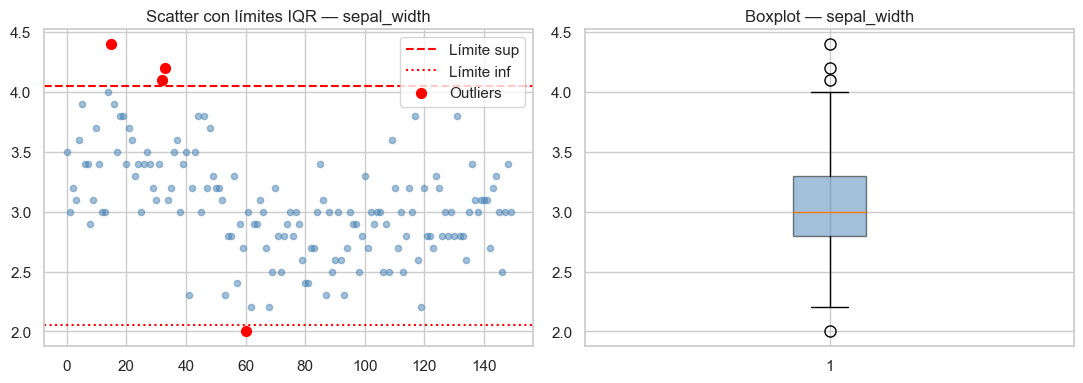

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

col = 'sepal_width'
Q1 = iris[col].quantile(0.25)
Q3 = iris[col].quantile(0.75)
IQR = Q3 - Q1
lim_sup = Q3 + 1.5 * IQR
lim_inf = Q1 - 1.5 * IQR

# Scatter de la variable con límites
axes[0].scatter(range(len(iris)), iris[col],
                color='steelblue', alpha=0.5, s=20)
axes[0].axhline(lim_sup, color='red', linestyle='--', label='Límite sup')
axes[0].axhline(lim_inf, color='red', linestyle=':', label='Límite inf')
mask = (iris[col] < lim_inf) | (iris[col] > lim_sup)
axes[0].scatter(np.where(mask)[0], iris[col][mask],
                color='red', s=50, zorder=5, label='Outliers')
axes[0].set_title(f'Scatter con límites IQR — {col}')
axes[0].legend()

# Boxplot con outliers marcados
bp = axes[1].boxplot(iris[col], patch_artist=True,
                     boxprops=dict(facecolor='steelblue', alpha=0.5),
                     flierprops=dict(marker='o', color='red',
                                     markersize=8))
axes[1].set_title(f'Boxplot — {col}')

plt.tight_layout()
plt.show()


### 10.4 Resumen de outliers por variable

In [18]:
numericas = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

resumen = []
for col in numericas:
    out_iqr, _, _ = detectar_outliers_iqr(iris[col])
    z   = np.abs(stats.zscore(iris[col]))
    M   = np.abs(zscore_modificado(iris[col]))
    resumen.append({
        'Variable': col,
        'Outliers IQR': len(out_iqr),
        'Outliers Z>3': (z > 3).sum(),
        'Outliers M>3.5': (M > 3.5).sum()
    })

pd.DataFrame(resumen)


,Variable,Outliers IQR,Outliers Z>3,Outliers M>3.5
0,sepal_length,0,0,0
1,sepal_width,4,1,0
2,petal_length,0,0,0
3,petal_width,0,0,0


---
## Clase 11 — Análisis Bivariado

### 11.1 Scatter plot


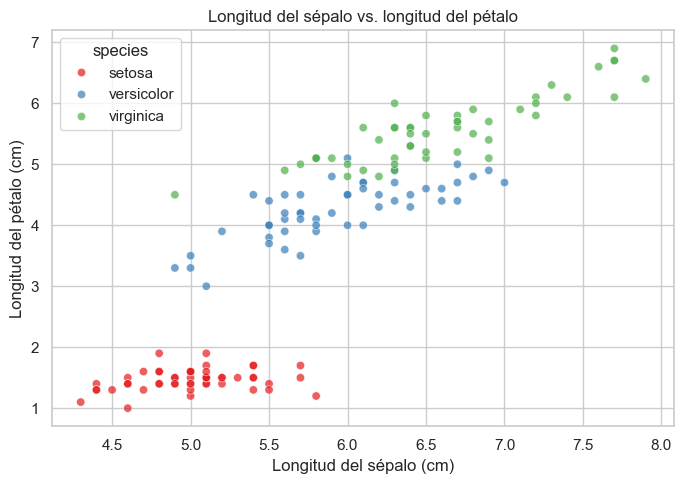

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.scatterplot(data=iris, x='sepal_length', y='petal_length',
                hue='species', palette='Set1', alpha=0.7, ax=ax)
ax.set_title('Longitud del sépalo vs. longitud del pétalo')
ax.set_xlabel('Longitud del sépalo (cm)')
ax.set_ylabel('Longitud del pétalo (cm)')
plt.tight_layout()
plt.show()


### 11.2 Correlación de Pearson

In [20]:
numericas = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
corr_pearson = iris[numericas].corr(method='pearson')
print("Matriz de correlación de Pearson:")
print(corr_pearson.round(3))


Matriz de correlación de Pearson:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000


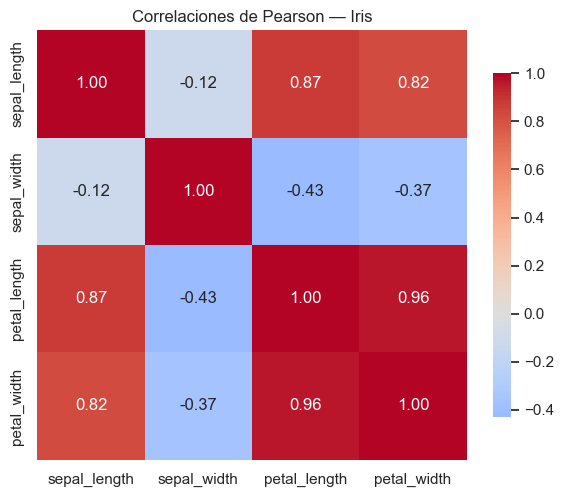

In [21]:
# Heatmap de correlación
fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr_pearson, dtype=bool), k=1)
sns.heatmap(corr_pearson, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            square=True, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlaciones de Pearson — Iris')
plt.tight_layout()
plt.show()


### 11.3 Correlación de Spearman

In [22]:
corr_spearman = iris[numericas].corr(method='spearman')
print("Matriz de correlación de Spearman:")
print(corr_spearman.round(3))


Matriz de correlación de Spearman:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.167         0.882        0.834
sepal_width         -0.167        1.000        -0.310       -0.289
petal_length         0.882       -0.310         1.000        0.938
petal_width          0.834       -0.289         0.938        1.000


### 11.4 Test de correlación con p-valor

In [23]:
from scipy.stats import pearsonr, spearmanr

x, y = iris['sepal_length'], iris['petal_length']

r_p, p_p = pearsonr(x, y)
r_s, p_s = spearmanr(x, y)

print(f"Pearson:  r = {r_p:.4f},  p = {p_p:.4e}")
print(f"Spearman: ρ = {r_s:.4f},  p = {p_s:.4e}")


Pearson:  r = 0.8718,  p = 1.0387e-47
Spearman: ρ = 0.8819,  p = 3.4431e-50


### 11.5 Variables cualitativas: tabla de contingencia

In [24]:
# tips: ¿Existe asociación entre día de la semana y momento del día?
tabla = pd.crosstab(tips['day'], tips['time'],
                    margins=True, margins_name='Total')
print(tabla)


time   Lunch  Dinner  Total
day                        
Thur      61       1     62
Fri        7      12     19
Sat        0      87     87
Sun        0      76     76
Total     68     176    244


In [25]:
from scipy.stats import chi2_contingency

tabla_obs = pd.crosstab(tips['day'], tips['time'])
chi2, p, gl, esperadas = chi2_contingency(tabla_obs)

print(f"Chi-cuadrado: {chi2:.4f}")
print(f"Grados de libertad: {gl}")
print(f"p-valor: {p:.4f}")
print()
# V de Cramér
n = tabla_obs.sum().sum()
V = np.sqrt(chi2 / (n * min(tabla_obs.shape[0]-1, tabla_obs.shape[1]-1)))
print(f"V de Cramér: {V:.4f}")


Chi-cuadrado: 217.1127
Grados de libertad: 3
p-valor: 0.0000

V de Cramér: 0.9433


### 11.6 Variable cualitativa vs. cuantitativa

C:\Users\jmbav\AppData\Local\Temp\ipykernel_24532\4202531415.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tips, x='day', y='total_bill',
C:\Users\jmbav\AppData\Local\Temp\ipykernel_24532\4202531415.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=tips, x='day', y='total_bill',


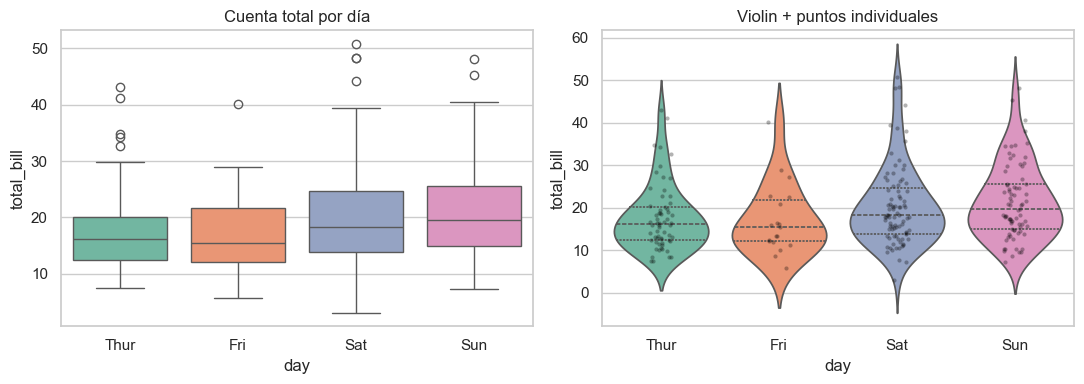

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Boxplot por grupo
sns.boxplot(data=tips, x='day', y='total_bill',
            ax=axes[0], palette='Set2')
axes[0].set_title('Cuenta total por día')

# Violin + strip
sns.violinplot(data=tips, x='day', y='total_bill',
               ax=axes[1], palette='Set2', inner='quartile')
sns.stripplot(data=tips, x='day', y='total_bill',
              ax=axes[1], color='black', alpha=0.3, size=3)
axes[1].set_title('Violin + puntos individuales')

plt.tight_layout()
plt.show()


---
## Clase 12 — Visualización con Python

### 12.1 Interfaz orientada a objetos de matplotlib


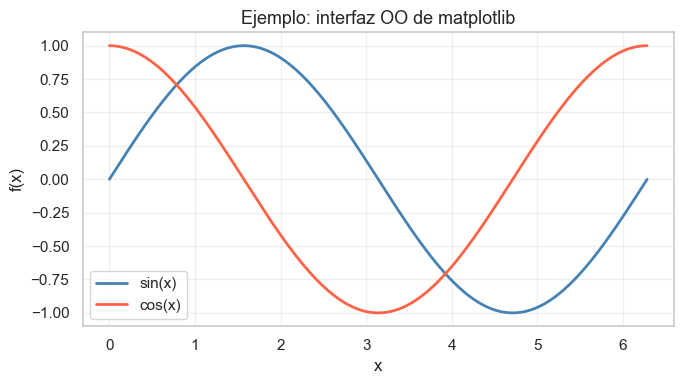

In [27]:
fig, ax = plt.subplots(figsize=(7, 4))

x = np.linspace(0, 2*np.pi, 300)
ax.plot(x, np.sin(x), color='steelblue', linewidth=2, label='sin(x)')
ax.plot(x, np.cos(x), color='tomato',    linewidth=2, label='cos(x)')

ax.set_title('Ejemplo: interfaz OO de matplotlib', fontsize=13)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 12.2 Panel múltiple con `subplots`

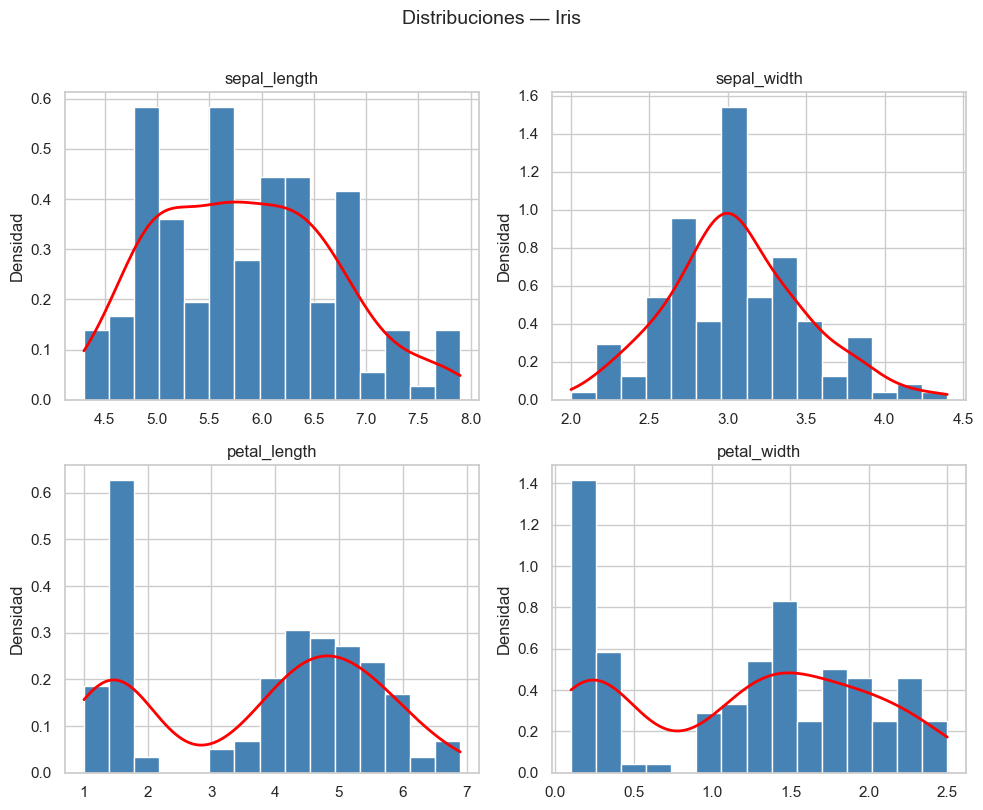

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

numericas = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

for ax, col in zip(axes.flatten(), numericas):
    ax.hist(iris[col], bins=15, color='steelblue', edgecolor='white', density=True)
    # KDE manual
    kde_x = np.linspace(iris[col].min(), iris[col].max(), 200)
    kde   = stats.gaussian_kde(iris[col])
    ax.plot(kde_x, kde(kde_x), color='red', lw=2)
    ax.set_title(col)
    ax.set_ylabel('Densidad')

plt.suptitle('Distribuciones — Iris', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


### 12.3 Pairplot con seaborn

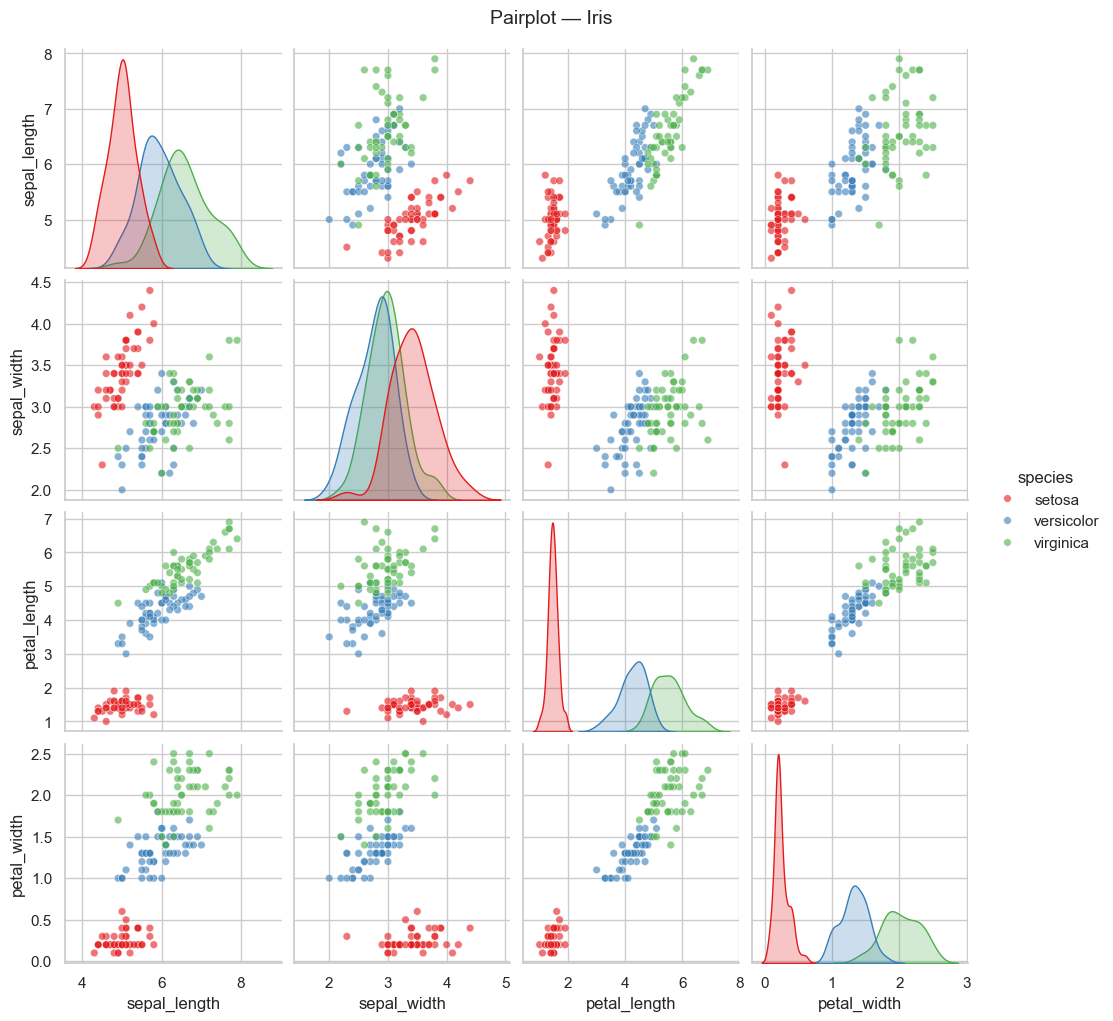

In [29]:
g = sns.pairplot(iris, hue='species', palette='Set1',
                 diag_kind='kde',
                 plot_kws={'alpha': 0.6, 's': 30})
g.fig.suptitle('Pairplot — Iris', y=1.02, fontsize=14)
plt.show()


### 12.4 Gráficos categóricos con seaborn

C:\Users\jmbav\AppData\Local\Temp\ipykernel_24532\670545124.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tips, x='day', y='tip',
C:\Users\jmbav\AppData\Local\Temp\ipykernel_24532\670545124.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tips, y='day', x='total_bill',


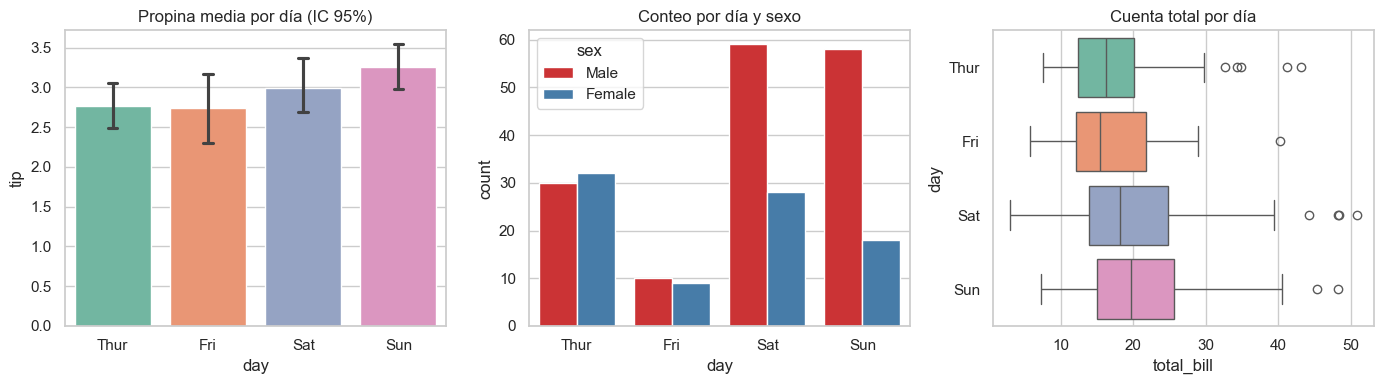

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Barplot con IC
sns.barplot(data=tips, x='day', y='tip',
            ax=axes[0], palette='Set2', capsize=0.1)
axes[0].set_title('Propina media por día (IC 95%)')

# Countplot
sns.countplot(data=tips, x='day', hue='sex',
              ax=axes[1], palette='Set1')
axes[1].set_title('Conteo por día y sexo')

# Boxplot horizontal
sns.boxplot(data=tips, y='day', x='total_bill',
            ax=axes[2], palette='Set2', orient='h')
axes[2].set_title('Cuenta total por día')

plt.tight_layout()
plt.show()


### 12.5 Facetas con `FacetGrid`

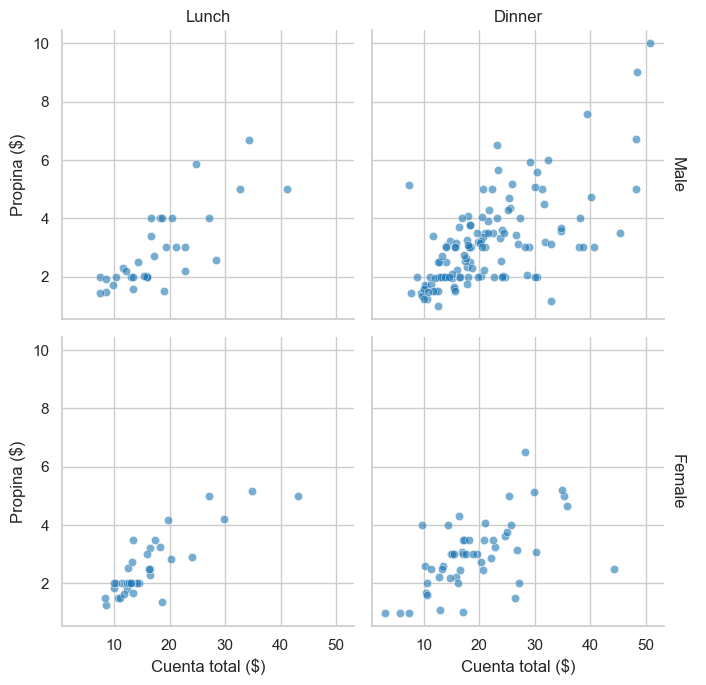

In [31]:
g = sns.FacetGrid(tips, col='time', row='sex',
                  margin_titles=True, height=3.5)
g.map(sns.scatterplot, 'total_bill', 'tip', alpha=0.6)
g.add_legend()
g.set_axis_labels('Cuenta total ($)', 'Propina ($)')
g.set_titles(col_template='{col_name}', row_template='{row_name}')
plt.show()


### 12.6 Exportación de figuras

Figuras guardadas.


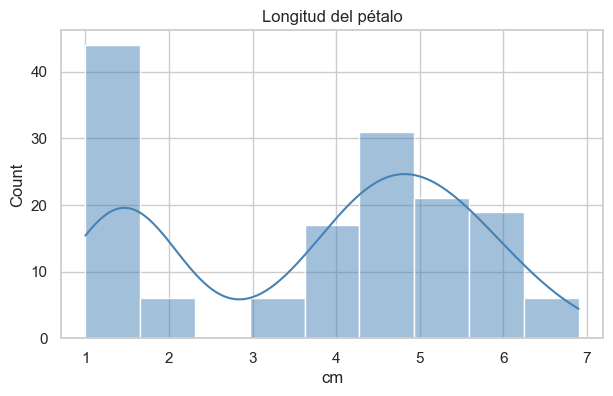

In [32]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(iris['petal_length'], kde=True, ax=ax, color='steelblue')
ax.set_title('Longitud del pétalo')
ax.set_xlabel('cm')

# Guardar como PDF (vectorial, ideal para publicaciones)
fig.savefig('figura_u2.pdf', bbox_inches='tight')

# Guardar como PNG (alta resolución)
fig.savefig('figura_u2.png', dpi=150, bbox_inches='tight')

print("Figuras guardadas.")
plt.show()


---
## Cierre de la Unidad 2

### Resumen de herramientas vistas

| Área | Función / Clase | Librería |
|------|----------------|----------|
| Descriptiva | `describe()`, `mean()`, `std()`, `quantile()` | pandas |
| Forma | `skew()`, `kurtosis()` | scipy.stats |
| Distribuciones | `histplot()`, `boxplot()`, `probplot()` | seaborn / scipy |
| Normalidad | `shapiro()`, `normaltest()` | scipy.stats |
| Outliers | IQR, Z-score, Z modificado (MAD) | numpy / scipy |
| Bivariado cuant. | `pearsonr()`, `spearmanr()`, `corr()` | scipy / pandas |
| Bivariado cual. | `crosstab()`, `chi2_contingency()` | pandas / scipy |
| Visualización | `matplotlib`, `seaborn`, `pairplot`, `FacetGrid` | matplotlib / seaborn |

**Unidad 3 → Regresión**
